# [LAB-07] 5. 독립표본 T-Test - 연습문제

## 준비작업

### 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *
from pandas import melt, DataFrame, pivot_table


📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


## 문제 1

material 데이터 셋은 어떤 화학 약품에 사용되는 서로 다른 상표의 주성분 A 함량표이다.    
상표에 따라 주성분 A의 함량에 어떤 차이가 있는지 검정하라.

In [2]:
df1 = load_data('material')
df1.head()

📚 어떤 화학 약품에 사용되는 서로 다른 상표의 주성분 A 함량표 (출처: 방송통신대학교 통계학개론)


,상표1,상표2
0,80.400,81.800
1,78.200,82.700
2,80.100,80.700
3,77.100,84.000
4,79.600,79.000


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

상표1 vs. 상표2: t-test independent samples, P_val:1.421e-01 t=-1.528e+00


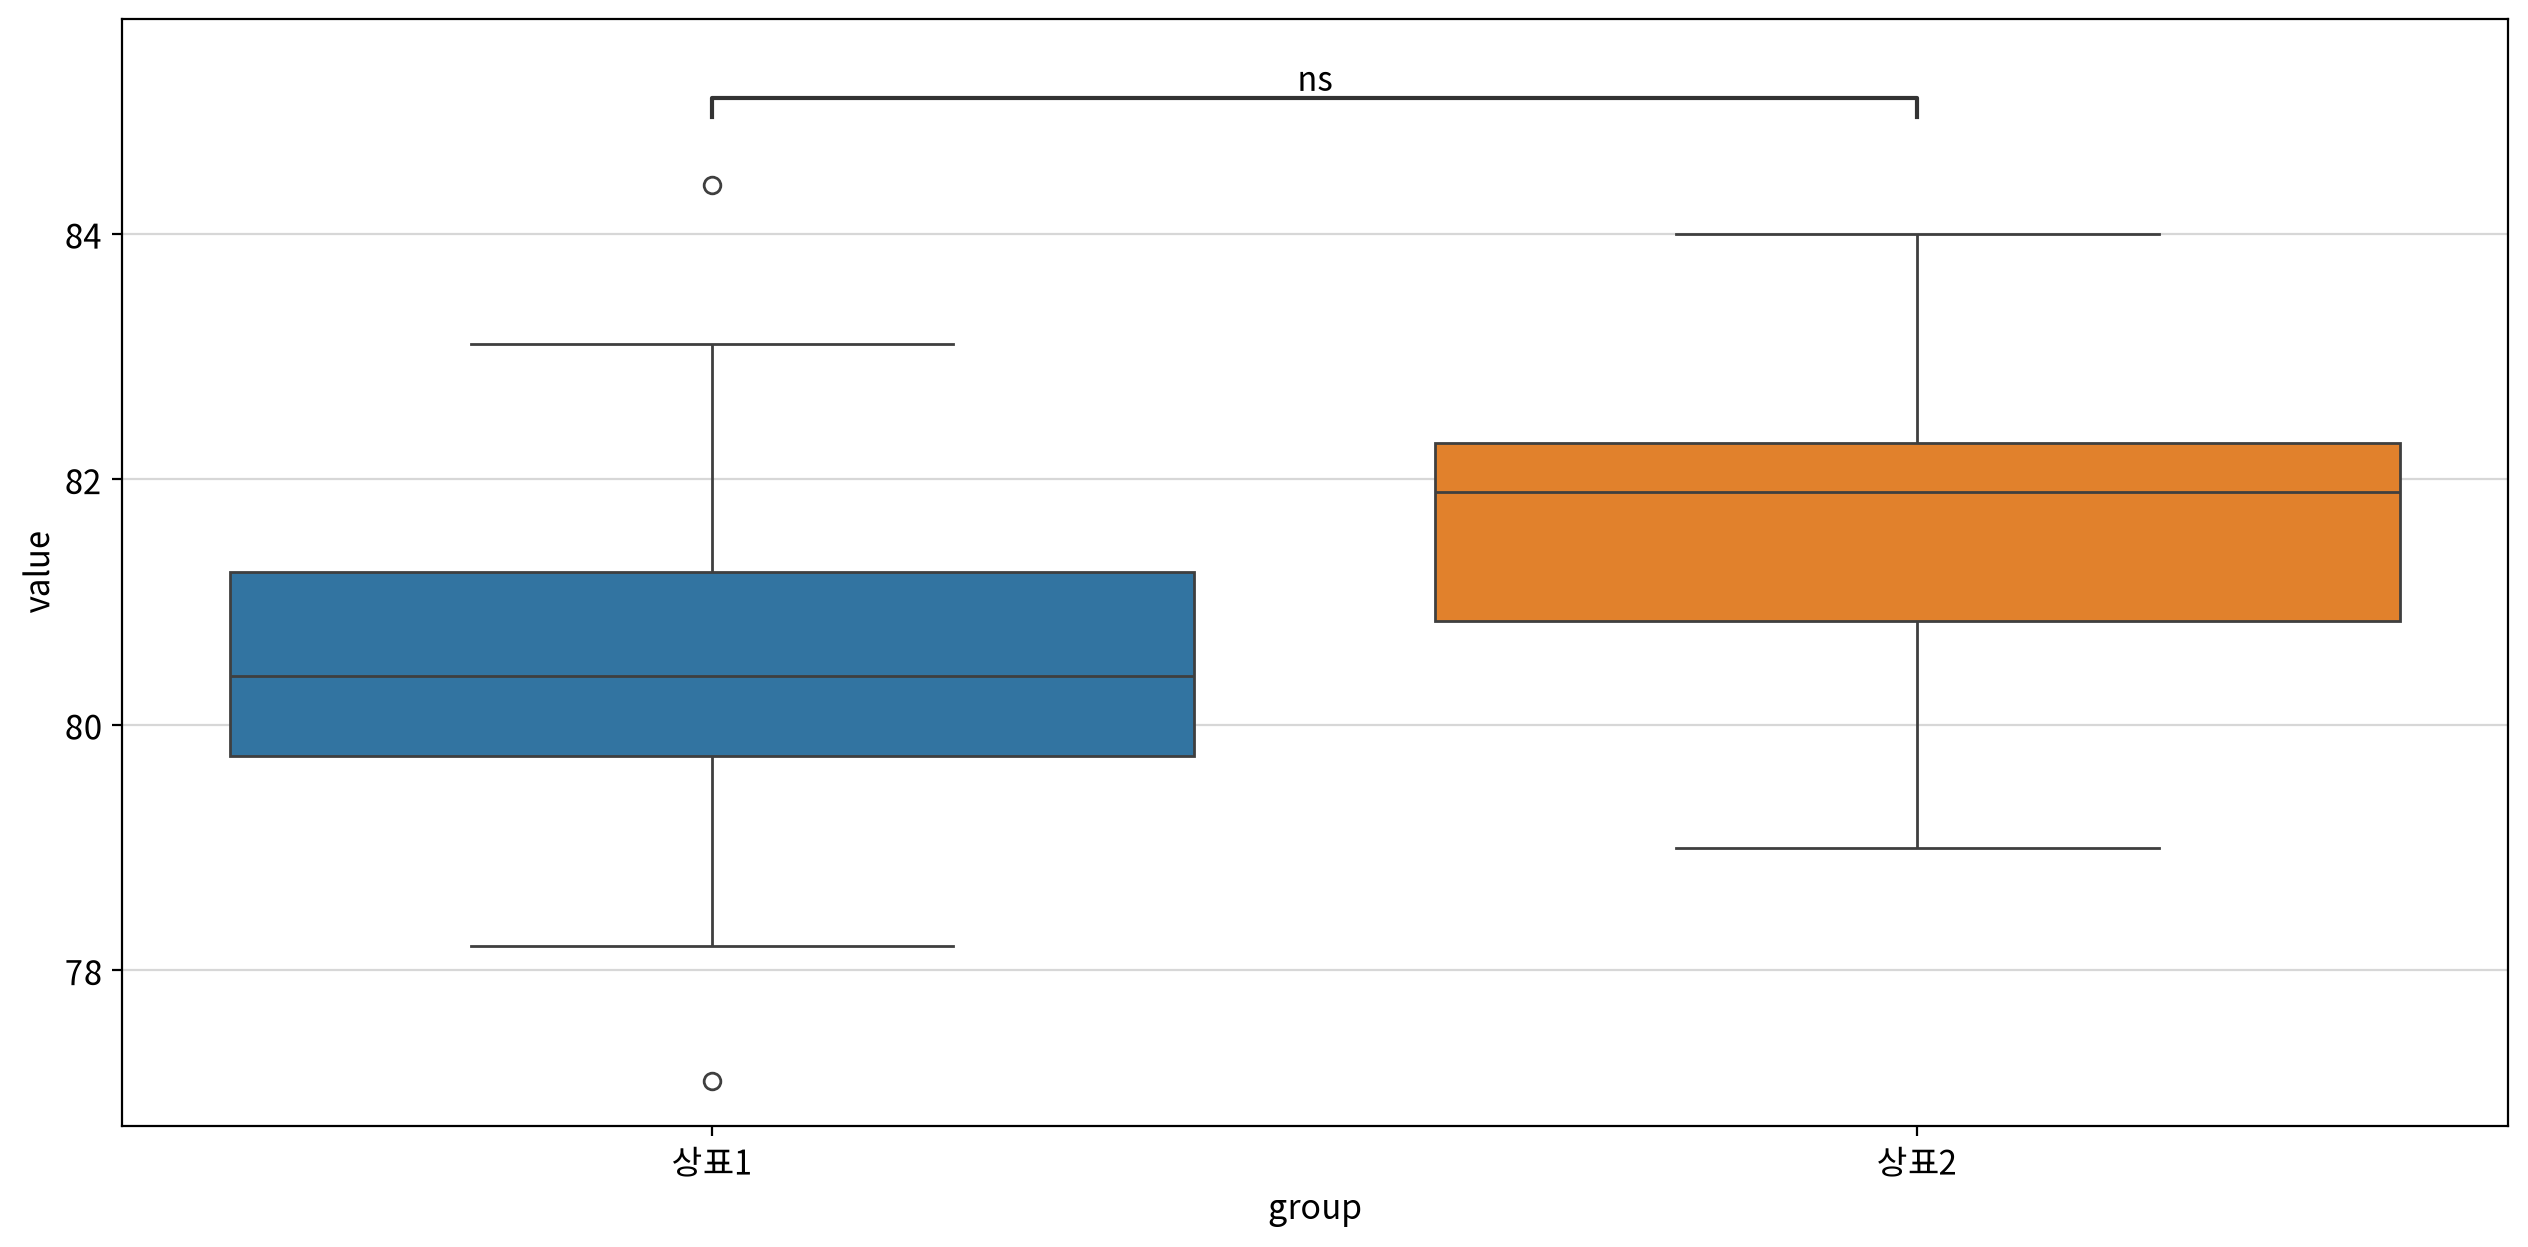

statistic  p-value  significant      result
test           alternative                                             
Student t-test two-sided       -1.528    0.142        False   상표1 = 상표2
               less            -1.528    0.071        False  상표1 >= 상표2
               greater         -1.528    0.929        False  상표1 <= 상표2

In [3]:
my_stats.test_independent(df1, '상표1', '상표2')

### 💡인사이트

양측검정 결과 검정통계량 `t = -1.528`, `p-value = 0.142`로 유의수준 0.05보다 크다.

따라서 귀무가설(상표1 = 상표2)을 기각할 수 없으며, **두 상표 간 주성분 A의 함량에는 통계적으로 유의한 차이가 없다**고 판단할 수 있다.

## 문제 2

adult_height 데이터셋은 성인 남여 30명의 성별(sex)과 신장(height) 데이터이다.    
남성과 여성의 평균 키에 어떤 차이가 있는지 검정하라.

In [4]:
df2 = load_data('adult_height')
df2

📚 성인 30명의 성별(sex), 신장(height) 데이터 (출처: 방송통신대학교 바이오통계학)


,sex,height
0,F,161
1,F,160
2,F,164
3,F,172
4,F,157
5,F,164
6,F,166
7,F,169
8,F,166
9,F,164


In [5]:
# 그룹별로 일련변호 생성
df2['idx'] = df2.groupby('sex').cumcount()
df2

,sex,height,idx
0,F,161,0
1,F,160,1
2,F,164,2
3,F,172,3
4,F,157,4
5,F,164,5
6,F,166,6
7,F,169,7
8,F,166,8
9,F,164,9


In [6]:
# df2를 wide 타입으로 변환 (성별 M/F에 따라 열 분리)
# pivot_table은 기본적으로 값을 집계하므로, 그룹 내 순번을 index로 넘겨 모든 값을 보존한다.
# cumcount로 성별 그룹별 순번을 만들어 index로 전달 (원래 입력 순서 유지).
df2_wide = pivot_table(
    df2,
    index='idx',
    columns='sex',
    values='height',
)
df2_wide.columns.name = None
df2_wide

,F,M
idx,,
0,161.000,166.000
1,160.000,157.000
2,164.000,171.000
3,172.000,174.000
4,157.000,170.000
5,164.000,172.000
6,166.000,165.000
7,169.000,182.000
8,166.000,170.000


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

M vs. F: t-test independent samples, P_val:4.477e-04 t=3.976e+00


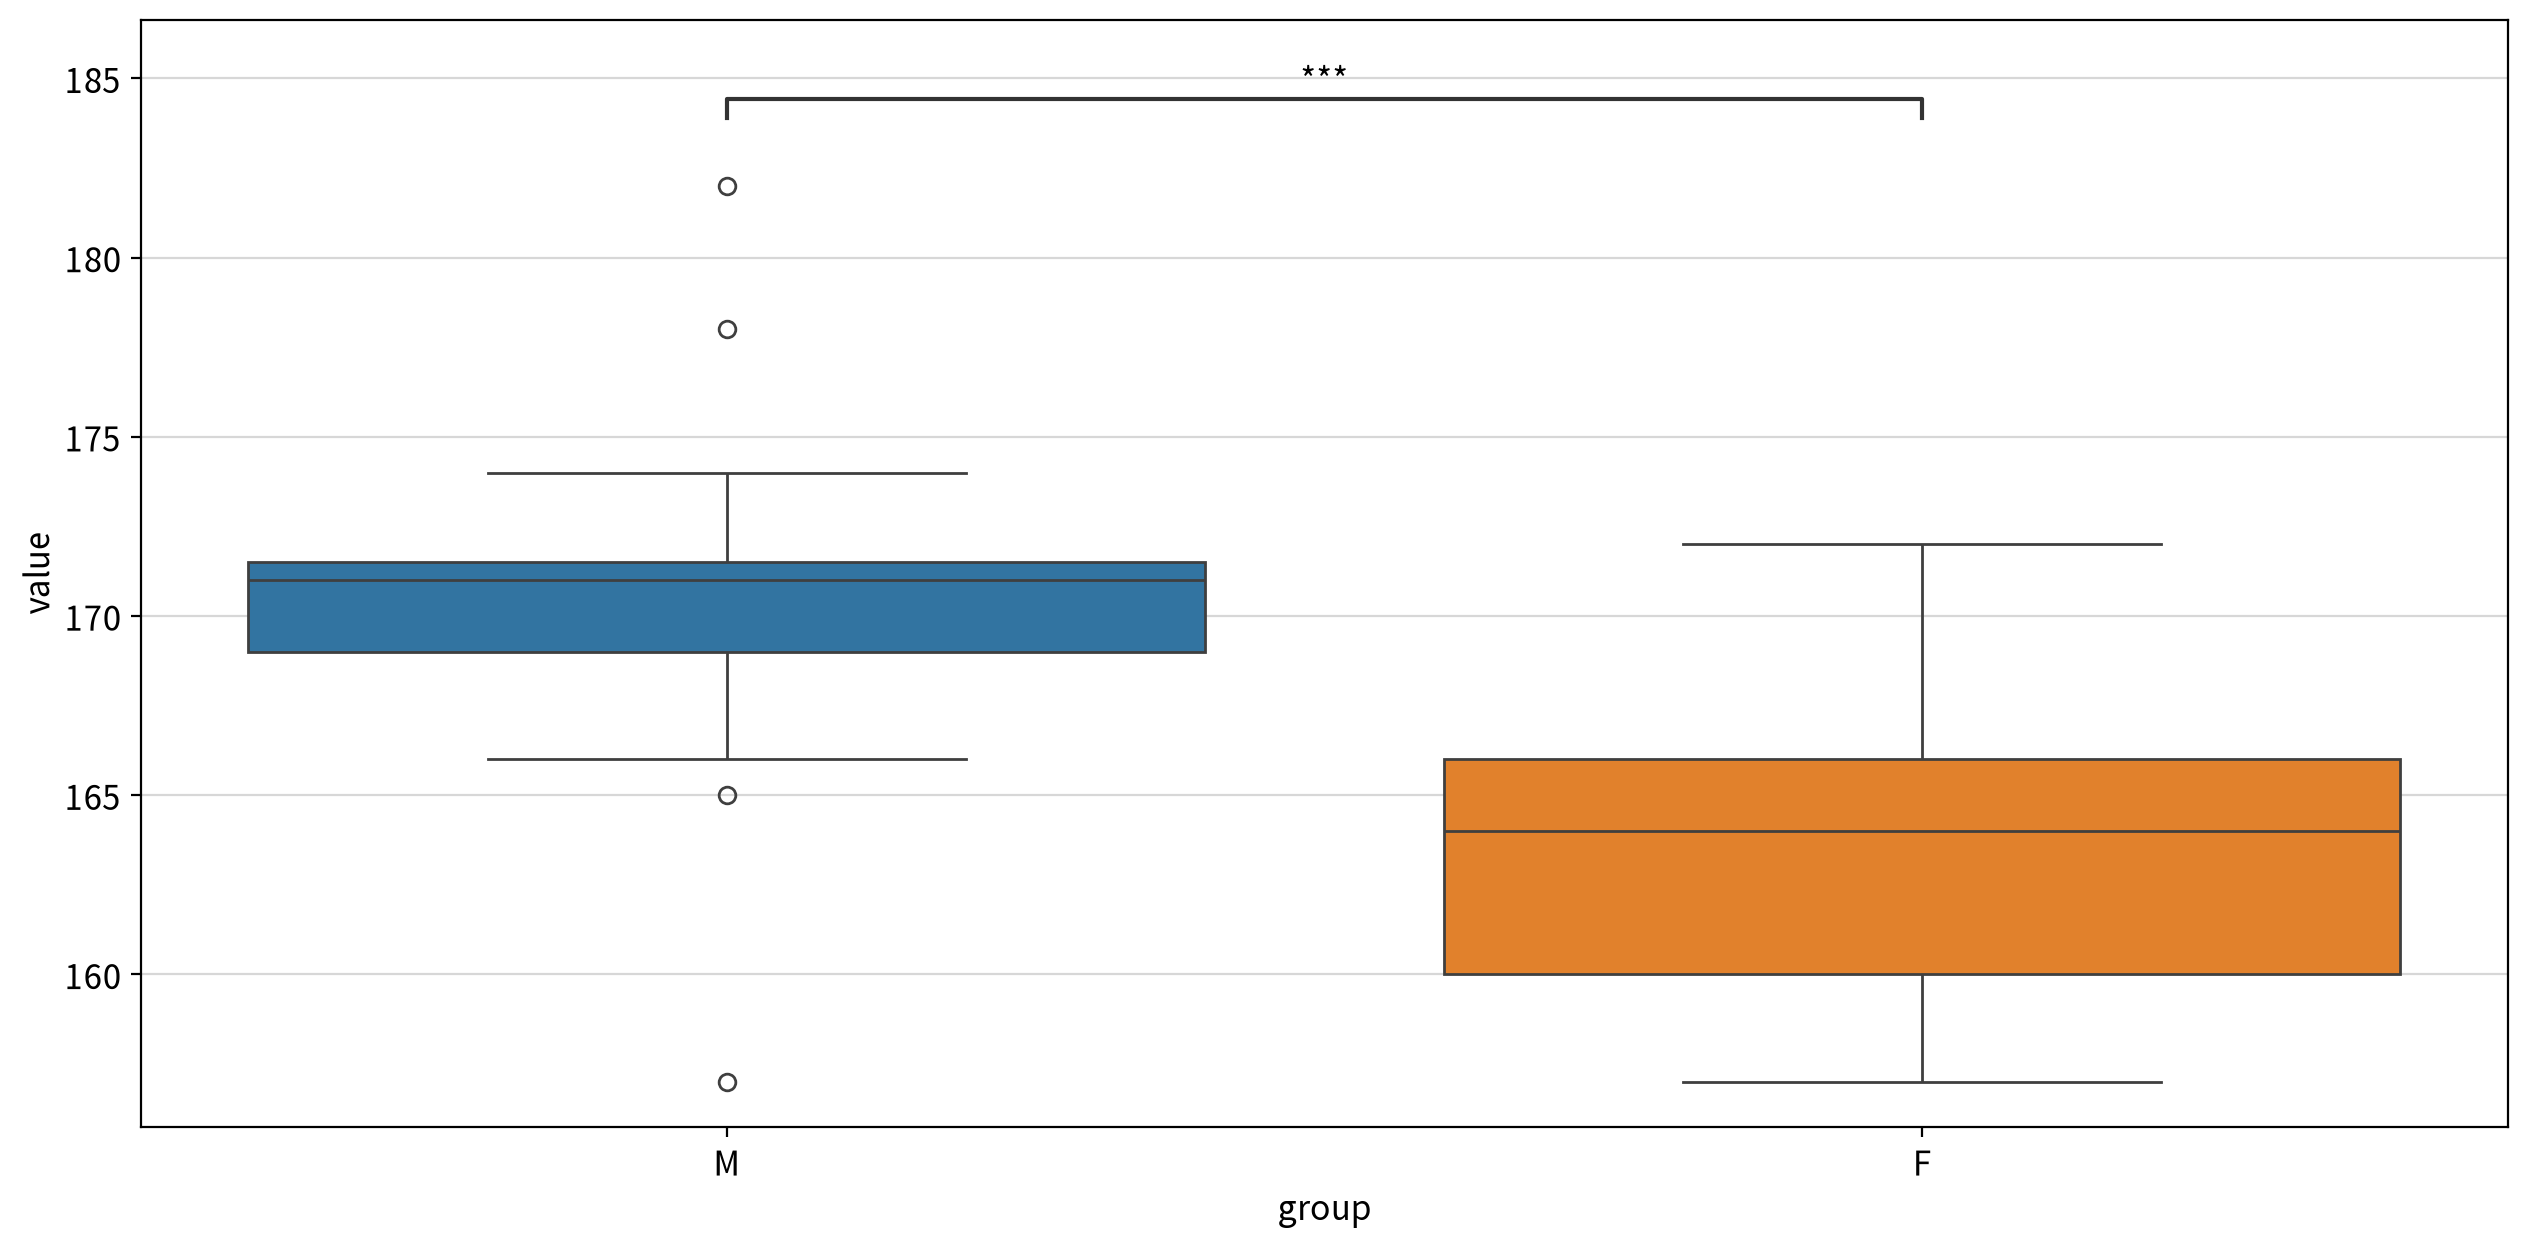

statistic  p-value  significant   result
test           alternative                                          
Student t-test two-sided        3.976    0.000         True  M =/= F
               less             3.976    1.000        False   M >= F
               greater          3.976    0.000         True    M < F

In [7]:
my_stats.test_independent(df2_wide, 'M', 'F')

### 💡인사이트

양측검정 결과 검정통계량 `t = 3.976`, `p-value = 0.0004`로 유의수준 0.05보다 작으므로 귀무가설(M = F)을 기각한다. 즉 **남성과 여성의 평균 키에는 통계적으로 유의한 차이가 있다.**

단측검정(greater)에서도 `p-value ≈ 0.000`으로 유의하므로, **남성의 평균 키가 여성보다 유의하게 크다**고 결론지을 수 있다.